In [1]:
%pip install numpy pandas matplotlib python-pptx

Note: you may need to restart the kernel to use updated packages.


In [129]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import Libraries (requirements)

In [130]:
import sys  # noqa
# sys.path.append('/workspace/forecasting_simulation')  # noqa
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns 
import matplotlib.colors as mcolors
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
import pandas.plotting as pd_plotting

from utils import *
from database import *


In [131]:
# Specify the folder name as 'images'
folder_path = 'image'  # Folder name 'images'
# Make sure the directory exists; if not, create it
if not os.path.exists(folder_path):
    os.makedirs(folder_path)


### Process data to return with kw

In [132]:
# client_data = load_profiles.hourly/ load_profiles.minutes
# Load your data
client_data = pd.read_excel('bounty_madera.xlsx')

In [133]:
def process_energy_data(client_data: pd.DataFrame) -> pd.DataFrame:
    client_data['datetime'] = pd.to_datetime(client_data['datetime'])

    # Calculate the average frequency dynamically
    avg_points_per_hour = client_data.resample(
        'h', on='datetime').count().hour.mean().round(0)

    kwh_column = 'kwh'
    kw_column = 'kw'

    # Dynamically calculate 'kw' based on the detected frequency
    if kwh_column in client_data.columns:
        if avg_points_per_hour > 0:  # Avoid division by zero or invalid cases
            frequency = avg_points_per_hour  # Simplified calculation
            client_data[kw_column] = client_data[kwh_column] * frequency
        else:
            # Default case for no transformation
            client_data[kw_column] = client_data[kwh_column]

    return client_data


In [134]:
processed_data = process_energy_data(client_data)

print(processed_data.head())

     client_name supply_period            datetime       date  correct_hour  \
0  bounty_madera    2023-09-30 2023-08-26 00:00:00 2023-08-26             0   
1  bounty_madera    2023-09-30 2023-08-26 01:00:00 2023-08-26             1   
2  bounty_madera    2023-09-30 2023-08-26 02:00:00 2023-08-26             2   
3  bounty_madera    2023-09-30 2023-08-26 03:00:00 2023-08-26             3   
4  bounty_madera    2023-09-30 2023-08-26 04:00:00 2023-08-26             4   

   hour  weekday      wesm      kwh       kw  
0     1        5  5.410817  433.182  433.182  
1     2        5  5.039229  416.093  416.093  
2     3        5  4.553897  414.557  414.557  
3     4        5  4.437269  405.076  405.076  
4     5        5  4.332006  439.397  439.397  


## Generate Energy Summary

In [135]:
processed_data

,client_name,supply_period,datetime,date,correct_hour,hour,weekday,wesm,kwh,kw
0,bounty_madera,2023-09-30,2023-08-26 00:00:00,2023-08-26,0,1,5,5.410817,433.182,433.182
1,bounty_madera,2023-09-30,2023-08-26 01:00:00,2023-08-26,1,2,5,5.039229,416.093,416.093
2,bounty_madera,2023-09-30,2023-08-26 02:00:00,2023-08-26,2,3,5,4.553897,414.557,414.557
3,bounty_madera,2023-09-30,2023-08-26 03:00:00,2023-08-26,3,4,5,4.437269,405.076,405.076
4,bounty_madera,2023-09-30,2023-08-26 04:00:00,2023-08-26,4,5,5,4.332006,439.397,439.397
...,...,...,...,...,...,...,...,...,...,...
9523,bounty_madera,2024-09-30,2024-09-25 19:00:00,2024-09-25,19,20,2,6.144656,550.646,550.646
9524,bounty_madera,2024-09-30,2024-09-25 20:00:00,2024-09-25,20,21,2,8.418051,542.412,542.412
9525,bounty_madera,2024-09-30,2024-09-25 21:00:00,2024-09-25,21,22,2,6.674139,525.861,525.861
9526,bounty_madera,2024-09-30,2024-09-25 22:00:00,2024-09-25,22,23,2,5.819909,529.344,529.344


In [136]:
# Generate energy summary (slide 1)
energy_summary = generate_energy_summary(client_data)
energy_summary

,supply_period,number of hours,kwh,kw,load factor
0,2023-09-30 00:00:00,744.00,"348,110.04",629.85,74.29%
1,2023-10-31 00:00:00,720.00,"354,161.26",630.88,77.97%
2,2023-11-30 00:00:00,744.00,"366,267.71",639.44,76.99%
3,2023-12-31 00:00:00,720.00,"356,928.48",653.81,75.82%
4,2024-01-31 00:00:00,744.00,"327,379.59",642.90,68.44%
5,2024-02-29 00:00:00,744.00,"305,358.59",618.89,66.32%
6,2024-03-31 00:00:00,696.00,"308,597.28",617.79,71.77%
7,2024-04-30 00:00:00,744.00,"362,519.50",631.87,77.11%
8,2024-05-31 00:00:00,720.00,"387,648.97",655.35,82.15%
9,2024-06-30 00:00:00,744.00,"340,091.73",586.11,77.99%


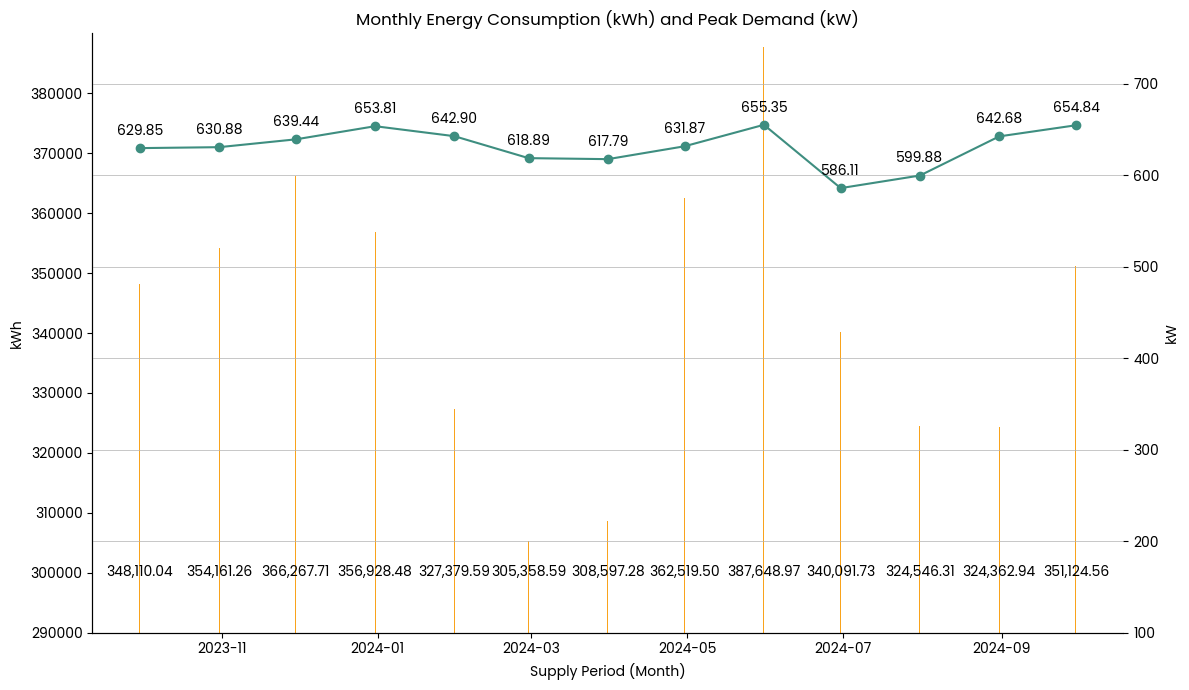

In [137]:
energy_consumption_plot(energy_summary)

## Plot Energy behavior

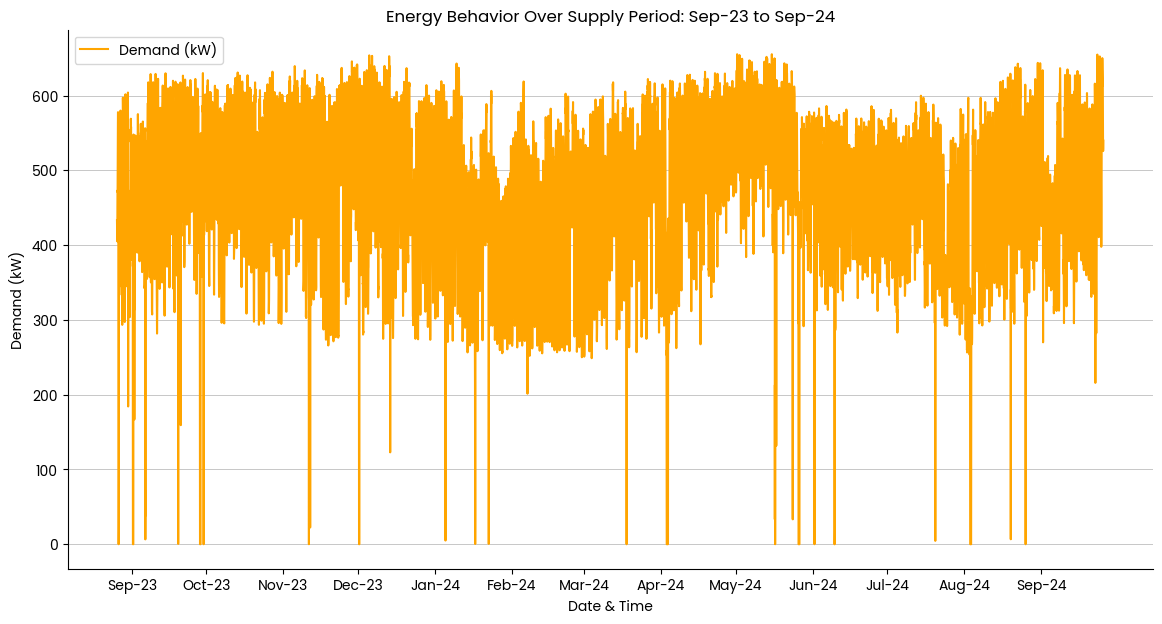

In [138]:
# Call the function to plot
energy_behavior_plot(client_data)

## Hourly Average Demand by Day

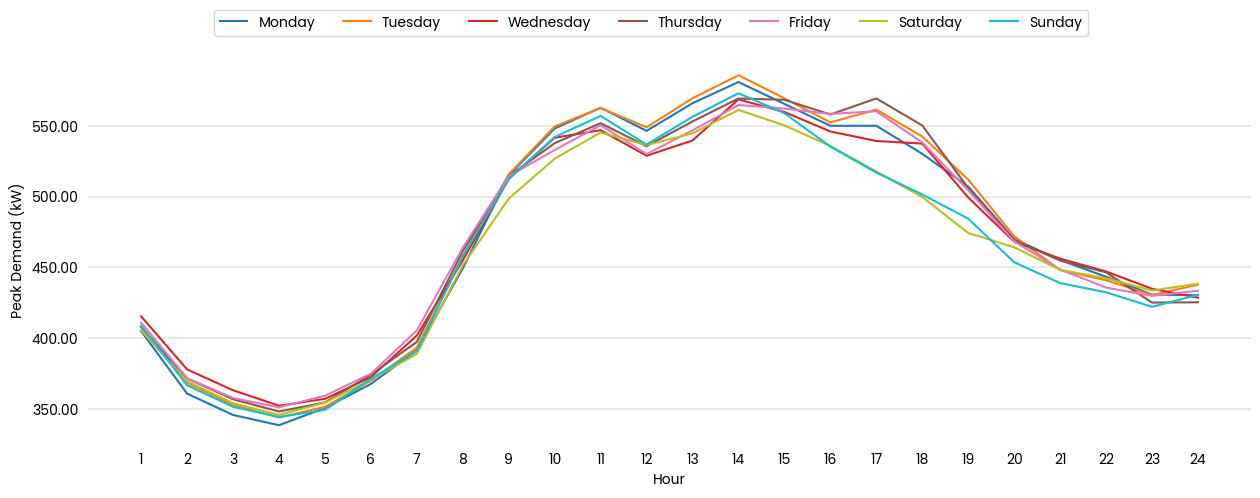

In [139]:
# Average by Hour
hourly_load_curve_by_day = client_data.pivot_table(
  index="hour",
  columns="weekday",
  values="kw",
  aggfunc={
    "kw": "mean"
  }
)
 
# Convert from kW to MW
# hourly_load_curve_by_day = hourly_load_curve_by_day / 1000
 
# Get list of days of the week
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
 
plot_hourly_by_day_load_curve(hourly_load_curve_by_day, column_name='max', unit='kW')

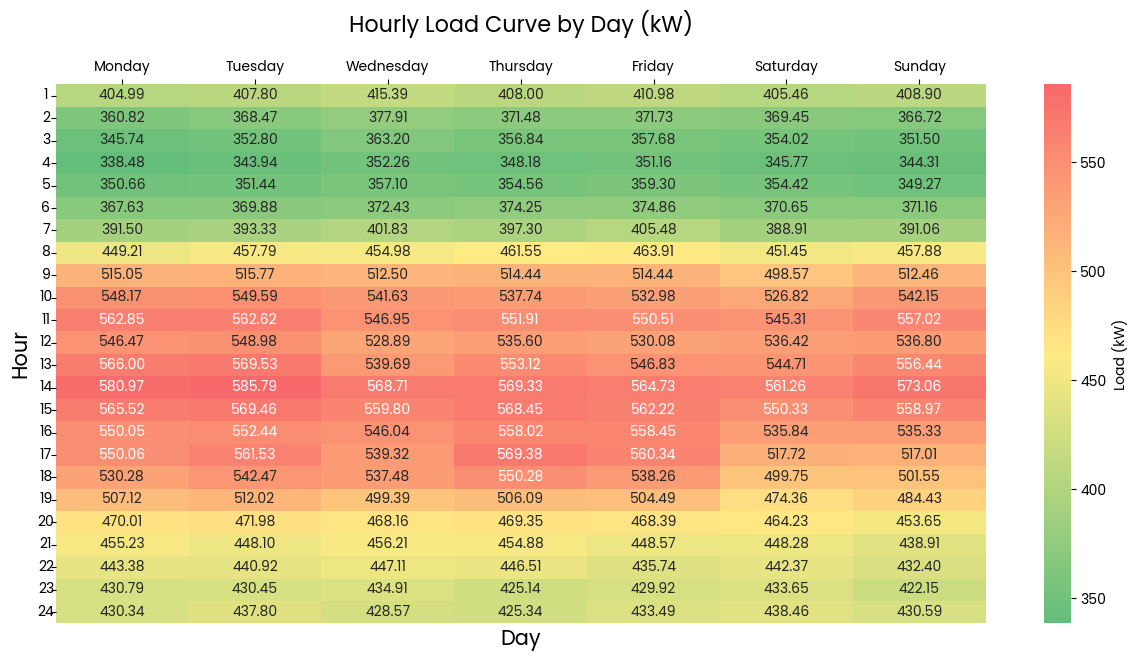

In [140]:
# Example call to the function
hourly_load_table(hourly_load_curve_by_day)


## Hourly Average Demand VS WESM

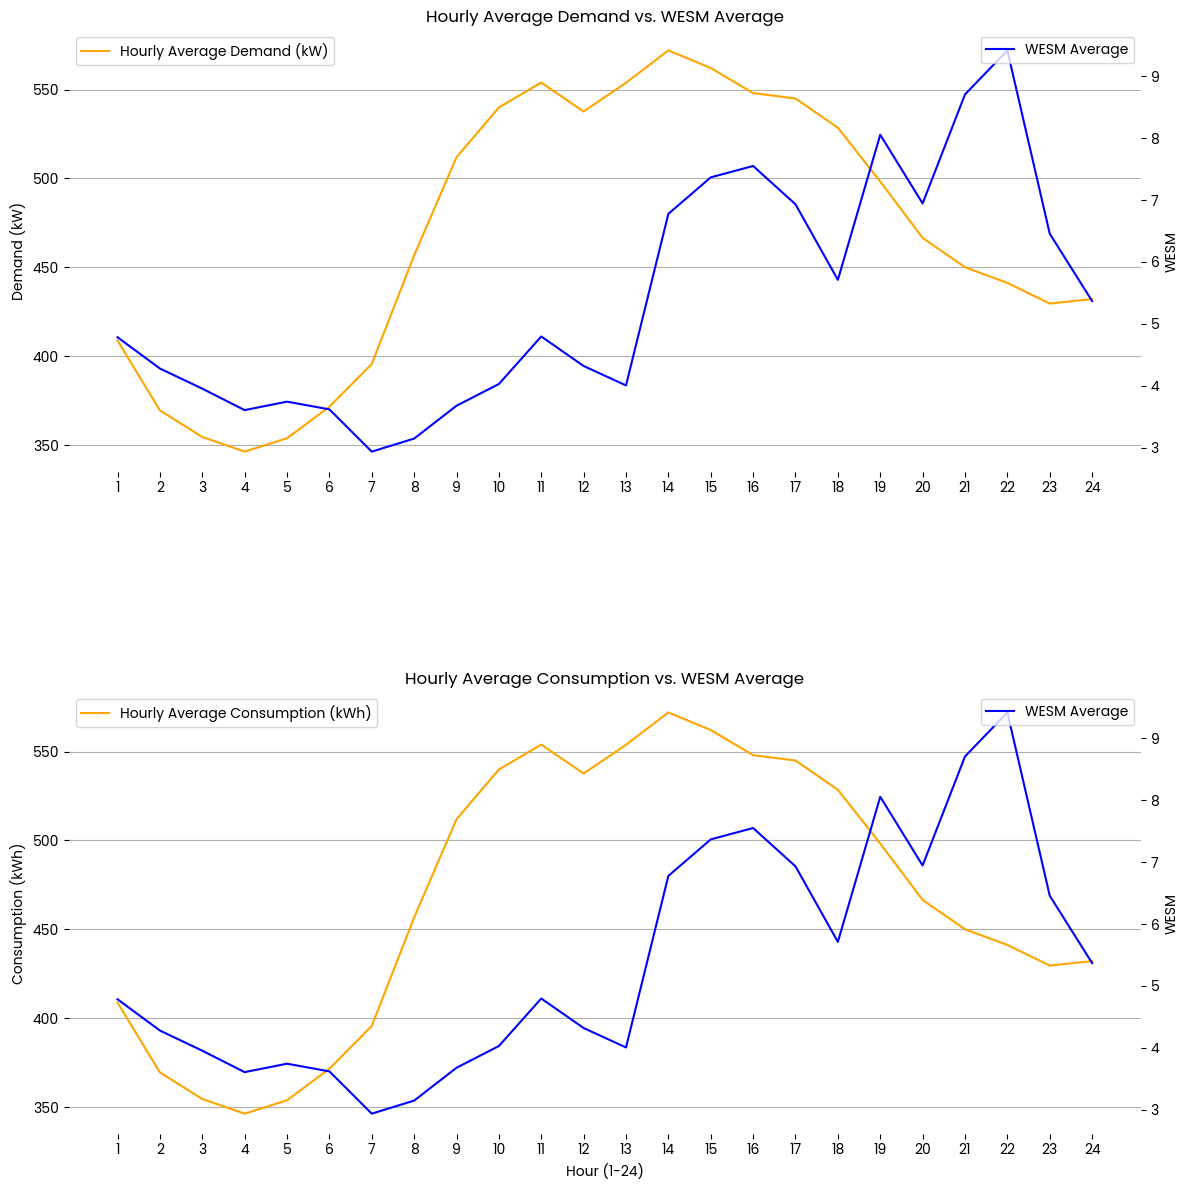

In [141]:
plot_demand_and_consumption_WESM(client_data)

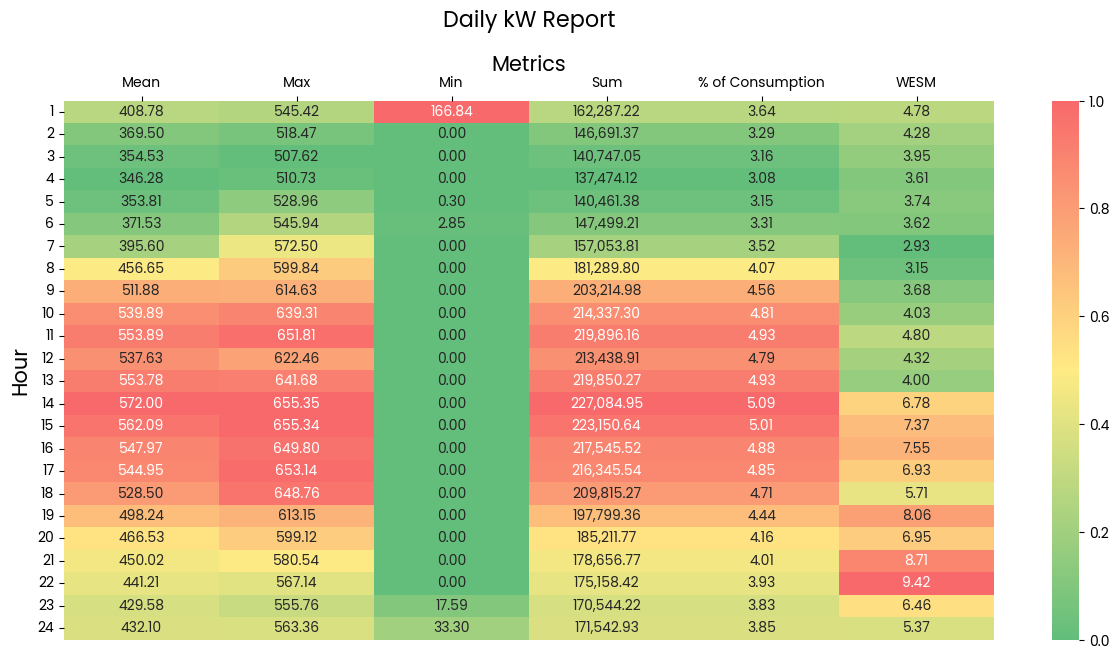

In [142]:
import seaborn as sns

# Call the function
generate_daily_report(
    client_data=client_data,        # Your input DataFrame
    values_column='kw',             # Column name for kW values
    wesm_column='wesm'        # Column name for WESM values    # Directory to save the heatmap
)

In [143]:
import os
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx import Presentation
import pandas as pd

# Get the current working directory where the Jupyter notebook is running
current_dir = os.getcwd()

# Define the relative paths for images
image_folder = os.path.join(current_dir, 'image')

# Ensure the image paths are correct
image_paths = {
    'energy_consumption': os.path.join(image_folder, 'energy_consumption.png'),
    'energy_behavior': os.path.join(image_folder, 'energy_bevahior.png'),
    'hourly_load_curve': os.path.join(image_folder, 'hourly_load_curve.png'),
    'peak_demand_plot': os.path.join(image_folder, 'peak_demand_plot.png'),
    'demand_consumption_wesm': os.path.join(image_folder, 'demand_consumption_wesm.png'),
    'daily_kw_report' : os.path.join(image_folder, 'daily_kw_report.png')
}

# Checking if images exist
for name, path in image_paths.items():
    if not os.path.exists(path):
        print(f"Image not found: {path}")
    else:
        print(f"Image found: {path}")

# Define the PowerPoint template path and output path
template_path = os.path.join(current_dir, 'solx.pptx')
output_path = os.path.join(current_dir, 'insights.pptx')

# Load the PowerPoint template
ppt = Presentation(template_path)
title_slide_layout = ppt.slide_layouts[0]  # Title slide
content_slide_layout = ppt.slide_layouts[1]  # Content slide
section_slide_layout = ppt.slide_layouts[3]  # Section slide
two_content_slide_layout = ppt.slide_layouts[4]  # Two content slide

Image found: c:\Users\MARK\Insights_Automation\image\energy_consumption.png
Image found: c:\Users\MARK\Insights_Automation\image\energy_bevahior.png
Image found: c:\Users\MARK\Insights_Automation\image\hourly_load_curve.png
Image found: c:\Users\MARK\Insights_Automation\image\peak_demand_plot.png
Image found: c:\Users\MARK\Insights_Automation\image\demand_consumption_wesm.png
Image found: c:\Users\MARK\Insights_Automation\image\daily_kw_report.png


In [144]:
# Function to add a table with content to a PowerPoint slide
def add_table_to_slide(slide, client_data, rows, cols, x, y, width, height):
    table = slide.shapes.add_table(rows, cols, x, y, width, height).table
    
    # Adjust column width for the first column
    table.columns[0].width = Inches(2.2)

    # Define the row header color (using RGB)
    row_header_color = RGBColor(249, 163, 28)

    # Rename the columns
    new_column_names = {
        'supply period': 'Supply Period',
        'number of hours': 'Total Hours',
        'kwh': 'Consumption(kWh)',
        'kw': 'Demand(kW)',
        'load factor': 'Load Factor'
    }
    
    # Add header with orange background and white font
    for col_idx, col_name in enumerate(client_data.columns):
        new_name = new_column_names.get(col_name.lower(), col_name)  # Get the new name if available
        cell = table.cell(0, col_idx)
        cell.text = str(new_name)
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(249, 163, 28)  # Orange
        cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)  # White
        cell.text_frame.paragraphs[0].font.size = Pt(12)  # Header font size
        cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER
    
    # Fill table with data and adjust font size for each cell
    for row_idx, row_data in enumerate(client_data.values):
        for col_idx, cell_value in enumerate(row_data):
            cell = table.cell(row_idx + 1, col_idx)  # +1 to skip the header row
            cell.text = str(cell_value)
            cell.text_frame.paragraphs[0].font.size = Pt(10)  # Font size for content
            cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        # Bold the rows for 'Total', 'Average', 'Max', 'Min'
        if row_data[0] in ['Total', 'Average', 'Max', 'Min']:
            for col_idx in range(cols):
                cell = table.cell(row_idx + 1, col_idx)
                cell.text_frame.paragraphs[0].font.bold = True  # Make the text bold

    return table

# Add a new slide with content layout
slide2 = ppt.slides.add_slide(content_slide_layout)
slide2.shapes.title.text = "Monthly kW, kWh Comparison & Load Factor​"

# Add the energy summary table to the slide
add_table_to_slide(slide2, energy_summary, rows=len(energy_summary)+1, cols=len(energy_summary.columns), 
                   x=Inches(0.4), y=Inches(2.0), width=Inches(13), height=Inches(5))

slide3 = ppt.slides.add_slide(content_slide_layout)
slide3.shapes.title.text = "Monthly Energy Consumption (kWh) and Peak Demand (kW)"
slide3.shapes.add_picture(image_paths['energy_consumption'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(12), height= Inches(5))
# pic = slide.shapes.add_picture('energy_consumption.png', left, top, height=Inches(5.5))

#Add 
slide4 = ppt.slides.add_slide(content_slide_layout)
slide4.shapes.title.text = "Load Graph"
slide4.shapes.add_picture(image_paths['energy_behavior'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(13), height= Inches(5))

#Add 
slide5 = ppt.slides.add_slide(content_slide_layout)
slide5.shapes.title.text = "Daily Average Demand"
slide5.shapes.add_picture(image_paths['hourly_load_curve'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(8), height= Inches(5.2))
slide5.shapes.add_picture(image_paths['peak_demand_plot'],
                         left= Inches(7), top= Inches(2),
                         width= Inches(5), height= Inches(5.2))

# Add a new slide with content layout
slide6 = ppt.slides.add_slide(content_slide_layout)
slide6.shapes.title.text = "Hourly Averages Demand​"
slide6.shapes.add_picture(image_paths['daily_kw_report'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(8), height= Inches(5.2))
slide6.shapes.add_picture(image_paths['demand_consumption_wesm'],
                         left= Inches(7), top= Inches(2),
                         width= Inches(5), height= Inches(5.2))
# Save the PowerPoint
ppt.save(output_path)

